In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datasets
from privacy_estimates.experiments.aml import JobList
from sklearn.metrics import roc_curve, roc_auc_score, auc

/anaconda/envs/privacy-estimates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def compute_performance(scores_members, scores_non_members):
    mia_performance = {}
    
    member_vals = [val for val in scores_members]
    non_member_vals = [val for val in scores_non_members]
    mia_performance['auc'] = roc_auc_score([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    fpr, tpr, thresholds = roc_curve([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    for target_fpr in (0.01, 0.05, 0.1):
        mia_performance[f'tpr_at_{target_fpr}'] = np.interp(target_fpr, fpr, tpr)
    print(f"AUC: {mia_performance['auc']}, TPR@0.01: {mia_performance['tpr_at_0.01']}, TPR@0.05: {mia_performance['tpr_at_0.05']}, TPR@0.1: {mia_performance['tpr_at_0.1']}")

    # also add the curves
    mia_performance['fpr'] = fpr
    mia_performance['tpr'] = tpr

    return mia_performance

# let's also make a function that computes the performance directly from the url

from datetime import datetime

def compute_performance_from_url(url, job_name = None):
    jobs = JobList.from_urls([url])
    if job_name is None:
        job_name = str(datetime.now())
    
    if not os.path.exists(f'./mia_results/{job_name}'):
        test = jobs[0].get_node('estimate_privacy').download_input('scores', f'./mia_results/{job_name}/scores')
        test = jobs[0].get_node('estimate_privacy').download_input('challenge_bits', f'./mia_results/{job_name}/challenge_bits')
    scores = datasets.load_from_disk(f'./mia_results/{job_name}/scores')
    bits = datasets.load_from_disk(f'./mia_results/{job_name}/challenge_bits')
    
    membership_scores = np.array([k['score'] for k in scores])
    membership_labels = np.array([k['challenge_bit'] for k in bits])
    members = membership_scores[membership_labels == 1]
    non_members = membership_scores[membership_labels == 0]
    return compute_performance(members, non_members)

## (1) Lets do it for SST-2

Vary neighbors k and see what happens to the mia performance, for both datasets.  

We ran the following:

`./scripts/launch_synthetic_mias_ablation_{DATASET}.sh > synthetic_mias_ablation_{DATASET}.txt`. For synthetic canaries, 12 repetitions, uniform label. 

Let's get these results. 

In [3]:
import re

def extract_aml_urls(log_file_path):
    # Initialize a list to store the extracted URLs
    aml_urls = []

    # Define a regular expression to match the log entries containing AML URLs
    aml_url_pattern = re.compile(r'AML URL: (https://ml\.azure\.com/runs/[\w\-\?&=/]+)')

    # Open and read the log file
    with open(log_file_path, 'r') as file:
        for line in file:
            match = aml_url_pattern.search(line)
            if match:
                aml_urls.append(match.group(1))

    return aml_urls

DATASET = 'sst2'

# Extract the AML URLs
aml_urls = extract_aml_urls(f'../synthetic_mias_ablation_{DATASET}.txt')
aml_urls

['https://ml.azure.com/runs/careful_pocket_3gcll6xlxm?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/olden_house_rr6qfnwmcm?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/busy_tail_c745p3f8wn?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/neat_tree_pm96dy6qmb?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/nifty_bread_d40hjhptxm?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-9

In [4]:
mia_methods=("jaccard_1", "jaccard_5", "jaccard_10", "jaccard_25",
             "embedding_1", "embedding_5", "embedding_10", "embedding_25",
             "ngram_1", "ngram_2", "ngram_3", "ngram_4")

In [5]:
method_to_auc = {}

for i, method in enumerate(mia_methods):
    job_name = f'ablation_synthetic_{method}'
    print(f"Processing {job_name}")
    performance = compute_performance_from_url(aml_urls[i])
    method_to_auc[method] = performance['auc']


Processing ablation_synthetic_jaccard_1


AUC: 0.5196578529391761, TPR@0.01: 0.005917159763313609, TPR@0.05: 0.05325443786982249, TPR@0.1: 0.11637080867850098
Processing ablation_synthetic_jaccard_5
AUC: 0.5353089205484275, TPR@0.01: 0.0039447731755424065, TPR@0.05: 0.03944773175542406, TPR@0.1: 0.1242603550295858
Processing ablation_synthetic_jaccard_10
AUC: 0.5381854843549335, TPR@0.01: 0.0019723865877712033, TPR@0.05: 0.0611439842209073, TPR@0.1: 0.10453648915187377
Processing ablation_synthetic_jaccard_25
AUC: 0.5473552816352005, TPR@0.01: 0.01775147928994083, TPR@0.05: 0.0670611439842209, TPR@0.1: 0.11439842209072978
Processing ablation_synthetic_embedding_1
AUC: 0.5158851134822425, TPR@0.01: 0.005917159763313609, TPR@0.05: 0.05325443786982249, TPR@0.1: 0.11242603550295859
Processing ablation_synthetic_embedding_5
AUC: 0.5155850546707155, TPR@0.01: 0.0039447731755424065, TPR@0.05: 0.0631163708086785, TPR@0.1: 0.1203155818540434
Processing ablation_synthetic_embedding_10
AUC: 0.5191217478625811, TPR@0.01: 0.005917159763313

Added the results in a table, still leave the code for figures too. 

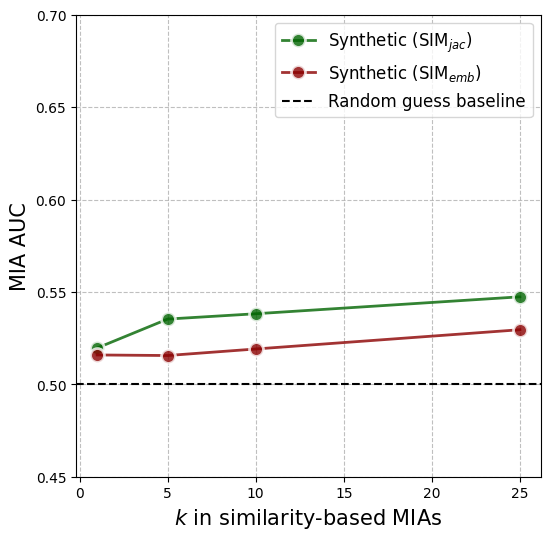

In [6]:
methods = ['ngram_loss_2', 'jaccard_25', 'embedding_10']

ks = [1, 5, 10, 25]

plt.figure(figsize=(6, 6))
plt.plot(ks, [method_to_auc[f'jaccard_{k}'] for k in ks], '-o', alpha=0.8, label=r'Synthetic ($\text{SIM}_{jac}$)', 
         color = 'darkgreen', markersize=10, linewidth=2, markeredgewidth=2, markeredgecolor='white')
plt.plot(ks, [method_to_auc[f'embedding_{k}'] for k in ks], '-o', alpha=0.8, label=r'Synthetic ($\text{SIM}_{emb}$)', 
         color = 'darkred', markersize=10, linewidth=2, markeredgewidth=2, markeredgecolor='white')
plt.xlabel(r'$k$ in similarity-based MIAs', fontsize=15)
plt.ylabel('MIA AUC', fontsize=15)
plt.grid(True, which="both", ls="--", alpha=0.8)
plt.axhline(y=0.5, color='black', linestyle='--', alpha=1.0, label = 'Random guess baseline')
plt.legend(fontsize=12)
plt.ylim(0.45, 0.7)
plt.savefig('figures/ablation_k.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

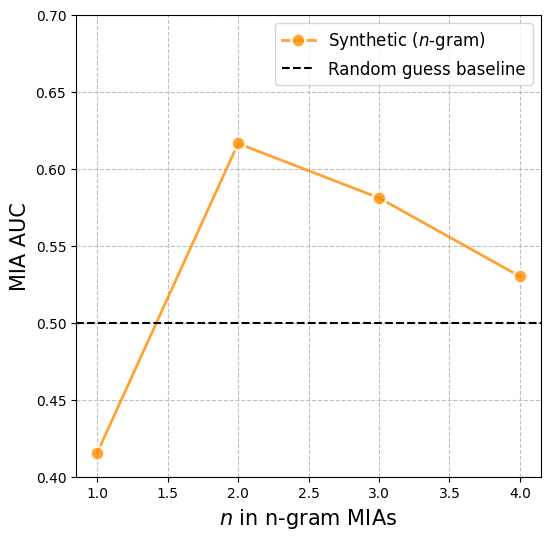

In [10]:
ns = [1, 2, 3, 4]

plt.figure(figsize=(6, 6))
plt.plot(ns, [method_to_auc[f'ngram_{n}'] for n in ns], '-o', alpha=0.8, label=r'Synthetic ($n$-gram)', 
         color = 'darkorange', markersize=10, linewidth=2, markeredgewidth=2, markeredgecolor='white')
plt.xlabel(r'$n$ in n-gram MIAs', fontsize=15)
plt.ylabel('MIA AUC', fontsize=15)
plt.grid(True, which="both", ls="--", alpha=0.8)
plt.axhline(y=0.5, color='black', linestyle='--', alpha=1.0, label = 'Random guess baseline')
plt.legend(fontsize=12)
plt.ylim(0.4, 0.7)
plt.savefig('figures/ablation_n.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## (2) Lets do it for AgNews

In [12]:
DATASET = 'agnews'

# Extract the AML URLs
aml_urls = extract_aml_urls(f'../synthetic_mias_ablation_{DATASET}.txt')
aml_urls

['https://ml.azure.com/runs/gifted_bucket_8tp337m1ld?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/gray_sugar_sx72yxv87k?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/heroic_sand_9r4490wqwn?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/witty_pump_rc5x2x3fyk?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/loving_plane_3d7d483bt6?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af

In [13]:
method_to_auc = {}

for i, method in enumerate(mia_methods):
    job_name = f'ablation_synthetic_{method}'
    print(f"Processing {job_name}")
    performance = compute_performance_from_url(aml_urls[i])
    method_to_auc[method] = performance['auc']


Processing ablation_synthetic_jaccard_1
AUC: 0.5223383783221511, TPR@0.01: 0.01775147928994083, TPR@0.05: 0.04930966469428008, TPR@0.1: 0.08284023668639054
Processing ablation_synthetic_jaccard_5
AUC: 0.5245308080383755, TPR@0.01: 0.0019723865877712033, TPR@0.05: 0.047337278106508875, TPR@0.1: 0.10059171597633136
Processing ablation_synthetic_jaccard_10
AUC: 0.537225296158047, TPR@0.01: 0.007889546351084813, TPR@0.05: 0.04930966469428008, TPR@0.1: 0.09861932938856016
Processing ablation_synthetic_jaccard_25
AUC: 0.5516161167588848, TPR@0.01: 0.005917159763313609, TPR@0.05: 0.0631163708086785, TPR@0.1: 0.11439842209072978
Processing ablation_synthetic_embedding_1
AUC: 0.5025264951930579, TPR@0.01: 0.005917159763313609, TPR@0.05: 0.055226824457593686, TPR@0.1: 0.14398422090729784
Processing ablation_synthetic_embedding_5
AUC: 0.49843769378798247, TPR@0.01: 0.005917159763313609, TPR@0.05: 0.05128205128205128, TPR@0.1: 0.1341222879684418
Processing ablation_synthetic_embedding_10
AUC: 0.50